# RYGB Gamut and Noise Ball Analysis

This notebook demonstrates:
1. Plotting the RYGB gamut (projected hypercube)
2. Plotting noise balls for different observers
3. Visualizing LMSQ cone basis vectors
4. Analyzing metamers across different observers in RYGB space


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:

import numpy as np
import sys
import tetrapolyscope as ps

from TetriumColor.Observer import Observer
from TetriumColor.ColorSpace import ColorSpace, ColorSpaceType, PolyscopeDisplayType
from TetriumColor.Observer.Spectra import Spectra, Illuminant
from TetriumColor.Visualization.PolyscopeUtils import (
    RenderNoiseBall, 
    RenderRYGBGamut, 
    RenderLMSQVectors,
    RenderDisplayGamut,
    RenderPointCloud,
    Render3DLine,
    RenderGamutSlices,
    RenderMetamericPairWithDirection
)
from TetriumColor.Observer.ObserverGenotypes import ObserverGenotypes

# Initialize polyscope
ps.init()
ps.set_transparency_render_passes(24)
ps.set_transparency_peel_epsilon(1e-7)  # Current default, should fix most z-fighting
ps.set_ground_plane_mode("none")


objc[59887]: Class GLFWHelper is implemented in both /Users/jessicalee/miniconda3/envs/tetriumcolor/lib/python3.11/site-packages/polyscope_bindings.cpython-311-darwin.so (0x112d8e728) and /Users/jessicalee/miniconda3/envs/tetriumcolor/lib/python3.11/site-packages/open3d/cpu/pybind.cpython-311-darwin.so (0x1337e7a28). One of the two will be used. Which one is undefined.
objc[59887]: Class GLFWApplicationDelegate is implemented in both /Users/jessicalee/miniconda3/envs/tetriumcolor/lib/python3.11/site-packages/polyscope_bindings.cpython-311-darwin.so (0x112d8e778) and /Users/jessicalee/miniconda3/envs/tetriumcolor/lib/python3.11/site-packages/open3d/cpu/pybind.cpython-311-darwin.so (0x1337e7a78). One of the two will be used. Which one is undefined.
objc[59887]: Class GLFWWindowDelegate is implemented in both /Users/jessicalee/miniconda3/envs/tetriumcolor/lib/python3.11/site-packages/polyscope_bindings.cpython-311-darwin.so (0x112d8e7a0) and /Users/jessicalee/miniconda3/envs/tetriumcolor/

[polyscope] Backend: openGL3_glfw -- Loaded openGL version: 4.1 Metal - 88.1


## Setup: Create Observers and Color Space

We'll create a standard tetrachromat observer and a ColorSpace with RYGB basis.
The RYGB basis uses cutpoints at [493, 563, 608] nm to define 4 spectral regions.


In [3]:
# Create standard tetrachromat observer
wavelengths = np.arange(360, 831, 1)
observer = Observer.tetrachromat(wavelengths=wavelengths)
print(f"Observer dimension: {observer.dimension}")
print(f"Wavelength range: {observer.wavelengths[0]}-{observer.wavelengths[-1]} nm")

# Create ColorSpace
cst = ColorSpace(observer)
print(f"\nColor space created for {observer.dimension}D observer")


Degree: 4, Macular: 0.908875, OD: 0.485
No illuminant provided, using Illuminant D65
Observer dimension: 4
Wavelength range: 360.0-830.0 nm

Color space created for 4D observer


## 1. Visualize RYGB Gamut

The RYGB gamut is a 4D hypercube in the Red-Yellow-Green-Blue basis.
We project it into 3D for visualization (dropping the luminance dimension).

**Note:** The RYGB basis uses cutpoints at [493, 563, 608] nm to create 4 spectral regions:
- **Blue**: wavelengths < 493 nm
- **Green**: 493-563 nm
- **Yellow**: 563-608 nm  
- **Red**: wavelengths > 608 nm

These regions form an orthogonal basis for tetrachromatic color space.


In [4]:
# Display basis to use (HERING_CONE drops luminance for 3D visualization)
display_basis = PolyscopeDisplayType.HERING_RYGB

# Render RYGB gamut
RenderRYGBGamut(
    "RYGB_Gamut",
    cst,
    display_basis,
    color=np.array([0.8, 0.8, 0.8]),
    alpha=0.3, 
    vertex_radius=0.015 * 2,
    edge_radius=0.003 * 2,
    scale=1.05
)

RenderGamutSlices(
    "rygb_gamut",
    cst,  # ColorSpace with display primaries
    ColorSpaceType.RYGB,
    display_basis,
    luminance_values=[0.5, 1.0, 1.50],
    grid_resolution=15,  # Higher = more points but slower
    alpha=0.2
)
print("RYGB gamut rendered!")
print("- Vertices represent all corners of the 4D hypercube")
print("- Edges connect vertices that differ in one RYGB coordinate")


Slice at L=0.50: 2272 points, alpha=0.20
Slice at L=1.00: 5535 points, alpha=0.25
Slice at L=1.50: 2272 points, alpha=0.30
RYGB gamut rendered!
- Vertices represent all corners of the 4D hypercube
- Edges connect vertices that differ in one RYGB coordinate


/Users/jessicalee/Projects/generalized-colorimetry/code/TetriumColor/TetriumColor/ColorSpace.py:593: RuntimeWarning: invalid value encountered in power
  1.055 * np.power(linear_rgb, 1/2.2) - 0.055)


## 2. Visualize LMSQ Cone Basis Vectors

The LMSQ vectors show the directions of the four cone types in the visualization space.


In [5]:
# Render LMSQ basis vectors
RenderLMSQVectors(
    "LMSQ_Vectors",
    cst,
    display_basis,
    scale=1.0,
    arrow_radius=0.005
)

print("LMSQ cone basis vectors rendered!")
print("- Red arrow: L cone (long wavelength)")
print("- Green arrow: M cone (medium wavelength)")
print("- Blue arrow: S cone (short wavelength)")
print("- Violet arrow: Q cone (extra medium wavelength)")


LMSQ cone basis vectors rendered!
- Red arrow: L cone (long wavelength)
- Green arrow: M cone (medium wavelength)
- Blue arrow: S cone (short wavelength)
- Violet arrow: Q cone (extra medium wavelength)


## 3. Generate Multiple Observers

We'll create several different tetrachromat observers with varying L, M, S, Q cone peak wavelengths to represent population diversity.


In [6]:
# Use ObserverGenotypes to get a diverse set of observers
genotypes = ObserverGenotypes()

# Get genotypes covering 99.9% of population
selected_genotypes = genotypes.get_genotypes_covering_probability(
    target_probability=0.999,
    sex='both'
)[:6]  # Take first 6 for visualization

# Add Q cone at 547 nm to make tetrachromats
tetrachromat_genotypes = [sorted((420, ) + g + (547,)) for g in selected_genotypes]

print(tetrachromat_genotypes)
# Create observers
observers = []
for i, genotype in enumerate[tuple[*tuple[float, ...], int]](tetrachromat_genotypes):
    obs = genotypes.get_observer_for_genotype(genotype)
    observers.append(obs)
    print(f"Observer {i+1}: S={genotype[0]}nm, M={genotype[1]}nm, L={genotype[2]}nm, Q={genotype[3]}nm")

# Create ColorSpaces for each observer
color_spaces = []
for obs in observers:
    cst = ColorSpace(obs)
    color_spaces.append(cst)

print(f"\nCreated {len(observers)} observers")


[[420, 530, 547, 559], [420, 530, 547, 555], [420, 533, 547, 559], [420, 547, 555, 559], [420, 533, 547, 555], [420, 530, 547, 556]]
Degree: 4, Macular: 0.908875, OD: 0.3875
Degree: 4, Macular: 0.908875, OD: 0.485
Degree: 4, Macular: 0.908875, OD: 0.485
Degree: 4, Macular: 0.908875, OD: 0.485
No illuminant provided, using Illuminant D65
Observer 1: S=420nm, M=530nm, L=547nm, Q=559nm
Degree: 4, Macular: 0.908875, OD: 0.3875
Degree: 4, Macular: 0.908875, OD: 0.485
Degree: 4, Macular: 0.908875, OD: 0.485
Degree: 4, Macular: 0.908875, OD: 0.485
No illuminant provided, using Illuminant D65
Observer 2: S=420nm, M=530nm, L=547nm, Q=555nm
Degree: 4, Macular: 0.908875, OD: 0.3875
Degree: 4, Macular: 0.908875, OD: 0.485
Degree: 4, Macular: 0.908875, OD: 0.485
Degree: 4, Macular: 0.908875, OD: 0.485
No illuminant provided, using Illuminant D65
Observer 3: S=420nm, M=533nm, L=547nm, Q=559nm
Degree: 4, Macular: 0.908875, OD: 0.3875
Degree: 4, Macular: 0.908875, OD: 0.485
Degree: 4, Macular: 0.90887

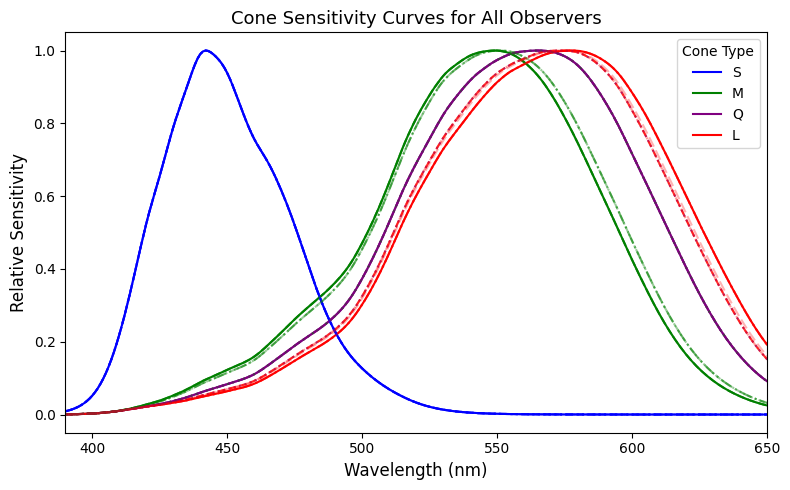

In [7]:
# Plot the cone sensitivity curves (observer.data) for each observer
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

cone_labels = ['S', 'M', 'Q', 'L']
cone_colors = ['b', 'g', 'purple', 'r']


# Use different opacities and line styles for different observers to distinguish them
# Define a list of alpha values and line styles
alphas = [1.0, 0.8, 0.6, 0.5, 0.4, 0.3]
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]

num_observers = len(observers)
for idx, observer in enumerate(observers):
    alpha_idx = idx % len(alphas)
    style_idx = idx % len(line_styles)
    for c in range(observer.sensor_matrix.shape[0]):
        # Show cone label only for the first observer to avoid legend clutter
        label = f"{cone_labels[c]}" if idx == 0 else None
        ax.plot(
            observer.wavelengths,
            observer.sensor_matrix[c, :],
            color=cone_colors[c],
            alpha=alphas[alpha_idx],
            linestyle=line_styles[style_idx],
            label=label
        )

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Relative Sensitivity", fontsize=12)
ax.set_title("Cone Sensitivity Curves for All Observers", fontsize=13)
ax.set_xlim(390, 650)

# Only unique legend entries for each cone type
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Cone Type", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Analyze Noise Balls in RYGB Space

For each observer, we'll:
1. Pick a test color in RYGB space
2. Add Gaussian noise to simulate measurement uncertainty
3. Visualize the noise ball (ellipsoid showing uncertainty)


In [8]:
# Define a test color in RYGB space (moderate values)
test_color_rygb = np.array([0.25, 0.5, 0.5, 0.25])

# Define noise levels (standard deviations) for each RYGB channel
# These could vary by observer based on discrimination thresholds
noise_levels = [
    np.array([0.1, 0.05, 0.05, 0.08]),  # Observer 1: higher Q noise
    np.array([0.1, 0.06, 0.05, 0.07]),  # Observer 2: higher M noise
    np.array([0.1, 0.04, 0.07, 0.06]),  # Observer 3: higher S noise
    np.array([0.1, 0.05, 0.06, 0.07]),  # Observer 4
    np.array([0.1, 0.04, 0.05, 0.06]),  # Observer 5: higher R noise
    np.array([0.1, 0.05, 0.04, 0.08]),  # Observer 6: higher Q noise
]

# Colors for each observer's noise ball
observer_colors = [
    np.array([1.0, 0.5, 0.5]),  # Light red
    np.array([0.5, 1.0, 0.5]),  # Light green
    np.array([0.5, 0.5, 1.0]),  # Light blue
    np.array([1.0, 1.0, 0.5]),  # Yellow
    np.array([1.0, 0.5, 1.0]),  # Magenta
    np.array([0.5, 1.0, 1.0]),  # Cyan
]

# Convert test color to display basis for each observer and render noise ball
for i, (obs, noise_std, color) in enumerate(zip(observers, noise_levels, observer_colors)):
    # Create ColorSpace for this observer
    obs_cst = ColorSpace(obs)
    
    # Convert test color from RYGB to CONE to display basis
    test_cone = obs_cst.convert(test_color_rygb.reshape(1, -1), ColorSpaceType.RYGB, ColorSpaceType.CONE)[0]
    test_display = obs_cst.convert_to_polyscope(
        test_cone.reshape(1, -1),
        ColorSpaceType.CONE,
        display_basis
    )[0]
    
    # Convert noise from RYGB space to display space
    # We'll convert the covariance ellipsoid
    noise_cone = obs_cst.convert(noise_std.reshape(1, -1), ColorSpaceType.RYGB, ColorSpaceType.CONE)[0]
    noise_display = obs_cst.convert_to_polyscope(
        noise_cone.reshape(1, -1),
        ColorSpaceType.CONE,
        display_basis
    )[0]
    
    # Render the noise ball
    RenderNoiseBall(
        f"Observer_{i+1}_NoiseBall",
        test_display,
        np.abs(noise_display),  # Use absolute values for std
        color=color,
        num_samples=500,
        alpha=0.4
    )
    
    # Mark the center point
    RenderPointCloud(
        f"Observer_{i+1}_Center",
        test_display.reshape(1, -1),
        color.reshape(1, -1),
        radius=0.02
    )
    
    print(f"Observer {i+1} noise ball rendered at center {test_display}")

print("\nAll noise balls rendered!")


(500, 3) (500, 3)
Observer 1 noise ball rendered at center [-0.14433757  0.10206207  0.1767767 ]
(500, 3) (500, 3)
Observer 2 noise ball rendered at center [-0.14433757  0.10206207  0.1767767 ]
(500, 3) (500, 3)
Observer 3 noise ball rendered at center [-0.14433757  0.10206207  0.1767767 ]
(500, 3) (500, 3)
Observer 4 noise ball rendered at center [-0.14433757  0.10206207  0.1767767 ]
(500, 3) (500, 3)
Observer 5 noise ball rendered at center [-0.14433757  0.10206207  0.1767767 ]
(500, 3) (500, 3)
Observer 6 noise ball rendered at center [-0.14433757  0.10206207  0.1767767 ]

All noise balls rendered!


In [9]:
# For tetrachromats, we need display primaries to find metamers
# Let's create example display primaries (would normally be measured)
from TetriumColor.Measurement import load_primaries_from_csv

primaries = load_primaries_from_csv("../../measurements/2025-12-02/primaries_old_method/", extract_zero=False)

In [10]:
# For each observer, generate metameric pairs
print("\nGenerating metameric pairs...\n")

metamer_pairs = []

for i, obs in enumerate(observers[:3]):  # Just first 3 for clarity
    # Create ColorSpace with display primaries
    obs_cst = ColorSpace(obs, display_primaries=primaries, metameric_axis=2)
    
    # Get maximal metameric pair along S-cone axis
    result = obs_cst.get_maximal_pair_in_disp_from_pt(
        pt=np.array([0.5, 0.5, 0.5, 0.5]),  # Center of display gamut
        metameric_axis=2,  # Q-cone axis
        input_space=ColorSpaceType.RYGB,
        output_space=ColorSpaceType.CONE,
    )
    
    if result is not None:
        cone1, cone2, metamer_diff = result
        print("cone1", cone1)
        print("cone2", cone2)
        print("metamer_diff", metamer_diff)
        
        # Convert to display space for visualization
        disp1 = obs_cst.convert_to_polyscope(
            cone1.reshape(1, -1),
            ColorSpaceType.CONE,
            display_basis
        )[0]
        
        disp2 = obs_cst.convert_to_polyscope(
            cone2.reshape(1, -1),
            ColorSpaceType.CONE,
            display_basis
        )[0]
        
        metamer_pairs.append((disp1, disp2))

        print(disp1)
        print(disp2 )
        
        # Visualize the metameric pair
        metamer_color = observer_colors[i]
        
        # Render both points
        RenderPointCloud(
            f"Metamer_{i+1}_Point1",
            disp1.reshape(1, -1),
            metamer_color.reshape(1, -1),
            radius=0.025
        )
        
        RenderPointCloud(
            f"Metamer_{i+1}_Point2",
            disp2.reshape(1, -1),
            (metamer_color * 0.7).reshape(1, -1),  # Slightly darker
            radius=0.025
        )
        
        # Connect them with a line
        Render3DLine(
            f"Metamer_{i+1}_Line",
            np.array([disp1, disp2]),
            metamer_color,
            radius=0.005
        )
        
        print(f"Observer {i+1}:")
        print(f"  Cone1: {cone1}")
        print(f"  Cone2: {cone2}")
        print(f"  Metamer difference: {metamer_diff:.4f}")
        print(f"  Distance in display space: {np.linalg.norm(disp2 - disp1):.4f}")
        print()
    else:
        print(f"Observer {i+1}: Could not find valid metameric pair\n")
        

print(f"\nVisualized {len(metamer_pairs)} metameric pairs")
print("Each pair shows two colors that look identical to that observer")
print("but differ in S-cone stimulation\n")



Generating metameric pairs...

cone1 [ 0.5         0.5         0.51240153  0.5       ]
cone2 [ 0.5         0.5         0.48759847  0.5       ]
metamer_diff 0.0248030551717
[ 0.07028098 -0.13078467  0.68180127]
[-0.07028098  0.13078467 -0.68180127]
Observer 1:
  Cone1: [ 0.5         0.5         0.51240153  0.5       ]
  Cone2: [ 0.5         0.5         0.48759847  0.5       ]
  Metamer difference: 0.0248
  Distance in display space: 1.3956

cone1 [ 0.5         0.5         0.50790034  0.5       ]
cone2 [ 0.5         0.5         0.49209966  0.5       ]
metamer_diff 0.0158006848839
[ 0.0759753  -0.09593238  0.65075443]
[-0.0759753   0.09593238 -0.65075443]
Observer 2:
  Cone1: [ 0.5         0.5         0.50790034  0.5       ]
  Cone2: [ 0.5         0.5         0.49209966  0.5       ]
  Metamer difference: 0.0158
  Distance in display space: 1.3243

cone1 [ 0.5         0.5         0.51053777  0.5       ]
cone2 [ 0.5         0.5         0.48946223  0.5       ]
metamer_diff 0.0210755421774
[

In [ ]:
ps.show()

RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP
RAYCAST_SPHERE
SPHERE_PROPAGATE_COLOR
SHADE_COLOR
LIGHT_MATCAP


: 